<a href="https://colab.research.google.com/github/dcsgod/aipnntemp/blob/main/AIPNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers torch numpy matplotlib seaborn tqdm

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM
from dataclasses import dataclass, field
from typing import List, Tuple, Optional, Dict
from tqdm import tqdm
import warnings
import json

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[Device] Using: {DEVICE}")
print(f"[CUDA]   {torch.cuda.get_device_name(0) if DEVICE == 'cuda' else 'N/A'}")


[Device] Using: cuda
[CUDA]   Tesla T4


In [ ]:
BACKBONE_MODEL = "gpt2"
print(f"\n[Loading] Backbone: {BACKBONE_MODEL}")
tokenizer = AutoTokenizer.from_pretrained(BACKBONE_MODEL)
tokenizer.pad_token = tokenizer.eos_token

backbone = AutoModelForCausalLM.from_pretrained(
    BACKBONE_MODEL,
    output_hidden_states=True,   # We need h_t for the PINN
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
).to(DEVICE).eval()

VOCAB_SIZE   = tokenizer.vocab_size
HIDDEN_DIM   = backbone.config.n_embd   # 1024 for gpt2-medium
print(f"[Ready]  Vocab={VOCAB_SIZE:,}  Hidden={HIDDEN_DIM}")


[Loading] Backbone: gpt2


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

[Ready]  Vocab=50,257  Hidden=768


In [ ]:
def compute_entropy(logits: torch.Tensor) -> float:
    """Shannon entropy of the next-token distribution. H = -Σ p log p"""
    probs = F.softmax(logits.float(), dim=-1)
    log_probs = F.log_softmax(logits.float(), dim=-1)
    H = -(probs * log_probs).sum().item()
    return H


def compute_max_entropy(vocab_size: int) -> float:
    """H_max = log(V) — uniform distribution over vocabulary."""
    return np.log(vocab_size)


def compute_order_parameter(H: float, H_max: float) -> float:
    """
    φ = 1 - H/H_max
    φ ≈ 0  →  disordered (gas) — hallucination risk
    φ ≈ 1  →  ordered   (solid) — repetition risk
    φ ∈ [0.3, 0.7]  →  liquid corridor (target)
    """
    return 1.0 - (H / H_max)


def compute_semantic_velocity(
    hidden_states: List[torch.Tensor],
    window: int = 3
) -> float:
    """
    Rate of change in embedding space over last `window` tokens.
    v_t = (1/window) Σ ||h_i - h_{i-1}||
    High v → rapid topic shift; Low v → repetition/stagnation
    """
    if len(hidden_states) < 2:
        return 0.0
    recent = hidden_states[-min(window + 1, len(hidden_states)):]
    velocities = []
    for i in range(1, len(recent)):
        delta = (recent[i] - recent[i - 1]).float()
        velocities.append(delta.norm().item())
    return float(np.mean(velocities)) if velocities else 0.0


@dataclass
class StepMetrics:
    """All physics metrics captured at one decoding step."""
    entropy:         float
    order_parameter: float
    velocity:        float
    temperature:     float
    token_id:        int
    token_str:       str

In [ ]:
class PINNController(nn.Module):
    """
    Physics-Informed Neural Network that acts as a dynamic thermostat.

    Inputs  (per step):
        h_t        — mean-pooled last hidden state     [hidden_dim]
        H_t        — current entropy                   [1]
        v_t        — semantic velocity                 [1]
        phi_t      — order parameter                   [1]

    Output:
        T_t        — instantaneous temperature scalar  [1]  ∈ [T_min, T_max]

    Architecture:
        Input projection → GRU (sequence memory) → MLP head → sigmoid → scale
    """

    # CONFIG ──────────────────────────────────────────────────────────
    T_MIN        = 0.1    # Minimum temperature (near-greedy)
    T_MAX        = 2.0    # Maximum temperature (high creativity)
    TARGET_PHI   = 0.50   # Target order parameter (liquid corridor center)
    PHI_MARGIN   = 0.20   # Acceptable deviation before strong correction
    GRU_HIDDEN   = 64
    MLP_HIDDEN   = 32
    INPUT_DIM    = None   # Set in __init__ based on backbone hidden dim
    # ─────────────────────────────────────────────────────────────────

    def __init__(self, backbone_hidden_dim: int):
        super().__init__()

        # Project backbone hidden state to compact representation
        self.proj = nn.Linear(backbone_hidden_dim, 32)

        # GRU captures the temporal dynamics (how things have been evolving)
        # Input: projected h + H + v + phi = 32 + 3 = 35
        self.gru = nn.GRU(
            input_size=35,
            hidden_size=self.GRU_HIDDEN,
            num_layers=1,
            batch_first=True
        )

        # MLP head maps GRU output → temperature
        self.head = nn.Sequential(
            nn.Linear(self.GRU_HIDDEN, self.MLP_HIDDEN),
            nn.Tanh(),
            nn.Linear(self.MLP_HIDDEN, 1),
            nn.Sigmoid()   # Output ∈ (0, 1), then scaled to [T_min, T_max]
        )

        self._gru_hidden = None   # Maintained across decoding steps
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def reset(self):
        """Call at the start of each new generation."""
        self._gru_hidden = None

    def forward(
        self,
        h_t: torch.Tensor,      # [hidden_dim]
        H_t: float,
        v_t: float,
        phi_t: float,
    ) -> float:
        """Returns instantaneous temperature T_t as a Python float."""
        # Normalize scalar inputs to roughly [0, 1]
        H_norm   = H_t / np.log(VOCAB_SIZE)
        v_norm   = min(v_t / 50.0, 1.0)   # empirically, velocity ~ O(10-100)
        phi_norm = float(phi_t)

        # Build input vector
        h_proj = self.proj(h_t.float().unsqueeze(0))   # [1, 32]
        scalars = torch.tensor(
            [[H_norm, v_norm, phi_norm]],
            dtype=torch.float32
        ).to(h_t.device)
        x = torch.cat([h_proj, scalars], dim=-1).unsqueeze(0)  # [1, 1, 35]

        # GRU step
        out, self._gru_hidden = self.gru(x, self._gru_hidden)
        out = out.squeeze(0)  # [1, 64]

        # Temperature output
        raw_T = self.head(out).squeeze()   # scalar in (0, 1)
        T = self.T_MIN + (self.T_MAX - self.T_MIN) * raw_T
        return T.item()

    def physics_loss(
        self,
        temperatures: torch.Tensor,   # [seq_len]
        entropies: torch.Tensor,       # [seq_len]
        order_params: torch.Tensor,    # [seq_len]
    ) -> torch.Tensor:
        """
        Physics-informed loss with three components:

        1. Phase Loss:    penalize when φ drifts outside liquid corridor
        2. FP Proxy Loss: penalize large ∂²T/∂t² (temperature must be smooth)
        3. Energy Loss:   low T when φ is near solid, high T when φ is near gas
        """
        # --- 1. Phase Loss ---
        # Penalty for being outside [TARGET_PHI ± PHI_MARGIN]
        phi_lo = self.TARGET_PHI - self.PHI_MARGIN
        phi_hi = self.TARGET_PHI + self.PHI_MARGIN
        phase_loss = (
            F.relu(phi_lo - order_params) +
            F.relu(order_params - phi_hi)
        ).mean()

        # --- 2. Fokker-Planck Proxy Loss (smoothness of T) ---
        if len(temperatures) >= 3:
            # Discrete second derivative of temperature sequence
            d2T = temperatures[2:] - 2 * temperatures[1:-1] + temperatures[:-2]
            fp_loss = (d2T ** 2).mean()
        else:
            fp_loss = torch.tensor(0.0)

        # --- 3. Energy Loss ---
        # When φ < phi_lo (gas/disordered), T should be LOW to stabilize
        # When φ > phi_hi (solid/ordered), T should be HIGH to diversify
        gas_mask   = (order_params < phi_lo).float()
        solid_mask = (order_params > phi_hi).float()
        energy_loss = (
            gas_mask   * temperatures +          # low T when gas
            solid_mask * (self.T_MAX - temperatures)  # high T when solid
        ).mean()

        total = phase_loss + 0.1 * fp_loss + 0.5 * energy_loss
        return total


In [ ]:
class ThermostatSampler:
    """
    Replaces standard top-p/greedy sampling with PINN-controlled temperature.

    At each step:
      1. Get logits + hidden state from backbone
      2. Compute H_t, v_t, φ_t
      3. Query PINN for T_t
      4. Apply temperature-scaled sampling
      5. Record all metrics
    """

    def __init__(self, backbone, tokenizer, pinn: PINNController):
        self.backbone  = backbone
        self.tokenizer = tokenizer
        self.pinn      = pinn.to(DEVICE)
        self.H_max     = compute_max_entropy(tokenizer.vocab_size)

    @torch.no_grad()
    def generate(
        self,
        prompt:         str,
        max_new_tokens: int  = 100,
        top_p:          float = 0.9,   # applied AFTER temperature scaling
    ) -> Tuple[str, List[StepMetrics]]:
        """Generate text using PINN-controlled temperature."""

        self.pinn.reset()
        input_ids = self.tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)
        hidden_history: List[torch.Tensor] = []
        metrics_log:   List[StepMetrics]   = []

        generated_ids = input_ids.clone()

        for step in range(max_new_tokens):
            outputs = self.backbone(
                generated_ids,
                output_hidden_states=True,
            )
            logits       = outputs.logits[0, -1, :]           # [vocab]
            # Last layer hidden state, last token position, mean across seq
            h_t          = outputs.hidden_states[-1][0, -1, :]  # [hidden_dim]

            # — Physics Probes —
            H_t   = compute_entropy(logits)
            phi_t = compute_order_parameter(H_t, self.H_max)
            hidden_history.append(h_t.cpu())
            v_t   = compute_semantic_velocity(hidden_history)

            # — PINN Temperature —
            T_t = self.pinn(h_t, H_t, v_t, phi_t)

            # — Temperature-Scaled Top-P Sampling —
            scaled_logits = logits / T_t
            next_token_id = self._top_p_sample(scaled_logits, top_p)

            # — Log —
            token_str = self.tokenizer.decode([next_token_id])
            metrics_log.append(StepMetrics(
                entropy=H_t,
                order_parameter=phi_t,
                velocity=v_t,
                temperature=T_t,
                token_id=next_token_id,
                token_str=token_str,
            ))

            # — Append token —
            next_id_tensor = torch.tensor([[next_token_id]], device=DEVICE)
            generated_ids  = torch.cat([generated_ids, next_id_tensor], dim=1)

            # — EOS check —
            if next_token_id == self.tokenizer.eos_token_id:
                break

        full_text = self.tokenizer.decode(generated_ids[0], skip_special_tokens=True)
        return full_text, metrics_log

    def _top_p_sample(self, logits: torch.Tensor, top_p: float) -> int:
        """Nucleus (top-p) sampling."""
        probs          = F.softmax(logits.float(), dim=-1)
        sorted_probs, sorted_idx = torch.sort(probs, descending=True)
        cumulative     = torch.cumsum(sorted_probs, dim=0)
        # Remove tokens with cumulative prob above threshold
        remove_mask    = (cumulative - sorted_probs) > top_p
        sorted_probs[remove_mask] = 0.0
        sorted_probs  /= sorted_probs.sum()
        chosen_pos     = torch.multinomial(sorted_probs, 1).item()
        return sorted_idx[chosen_pos].item()

In [ ]:
class BaselineSampler:
    """Standard fixed-temperature Top-P and Greedy samplers."""

    def __init__(self, backbone, tokenizer):
        self.backbone  = backbone
        self.tokenizer = tokenizer
        self.H_max     = compute_max_entropy(tokenizer.vocab_size)

    @torch.no_grad()
    def generate(
        self,
        prompt:         str,
        max_new_tokens: int   = 100,
        temperature:    float = 1.0,
        top_p:          float = 0.9,
        mode:           str   = "top_p",  # "top_p" | "greedy"
    ) -> Tuple[str, List[StepMetrics]]:

        input_ids    = self.tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)
        generated_ids = input_ids.clone()
        metrics_log: List[StepMetrics] = []

        for _ in range(max_new_tokens):
            outputs      = self.backbone(generated_ids, output_hidden_states=True)
            logits       = outputs.logits[0, -1, :]
            H_t          = compute_entropy(logits)
            phi_t        = compute_order_parameter(H_t, self.H_max)

            if mode == "greedy":
                next_token_id = logits.argmax().item()
            else:
                scaled = logits / temperature
                probs  = F.softmax(scaled.float(), dim=-1)
                sorted_p, sorted_idx = torch.sort(probs, descending=True)
                cum    = torch.cumsum(sorted_p, dim=0)
                remove = (cum - sorted_p) > top_p
                sorted_p[remove] = 0.0
                sorted_p /= sorted_p.sum()
                next_token_id = sorted_idx[torch.multinomial(sorted_p, 1).item()].item()

            token_str = self.tokenizer.decode([next_token_id])
            metrics_log.append(StepMetrics(
                entropy=H_t,
                order_parameter=phi_t,
                velocity=0.0,
                temperature=temperature,
                token_id=next_token_id,
                token_str=token_str,
            ))

            next_id_tensor = torch.tensor([[next_token_id]], device=DEVICE)
            generated_ids  = torch.cat([generated_ids, next_id_tensor], dim=1)
            if next_token_id == self.tokenizer.eos_token_id:
                break

        full_text = self.tokenizer.decode(generated_ids[0], skip_special_tokens=True)
        return full_text, metrics_log


In [ ]:
def train_pinn(
    pinn:           PINNController,
    backbone,
    tokenizer,
    prompts:        List[str],
    epochs:         int   = 5,
    lr:             float = 3e-4,
    max_tokens:     int   = 60,
) -> List[float]:
    """
    Train the PINN controller using physics loss only (no labels needed).

    Strategy:
      1. Run a partial generation with the PINN
      2. Collect the temperature, entropy, and φ sequences
      3. Backprop through the physics loss
    """
    optimizer    = torch.optim.Adam(pinn.parameters(), lr=lr)
    H_max        = compute_max_entropy(tokenizer.vocab_size)
    loss_history = []

    pinn.train().to(DEVICE)
    print(f"\n[Training PINN] {epochs} epochs × {len(prompts)} prompts")

    for epoch in range(epochs):
        epoch_losses = []
        for prompt in tqdm(prompts, desc=f"Epoch {epoch+1}/{epochs}"):
            optimizer.zero_grad()
            pinn.reset()

            input_ids     = tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)
            generated_ids = input_ids.clone()
            hidden_history: List[torch.Tensor] = []

            temps_list  = []
            phis_list   = []
            entropy_list = []

            for step in range(max_tokens):
                with torch.no_grad():
                    outputs = backbone(generated_ids, output_hidden_states=True)
                    logits  = outputs.logits[0, -1, :]
                    h_t     = outputs.hidden_states[-1][0, -1, :]

                H_t   = compute_entropy(logits)
                phi_t = compute_order_parameter(H_t, H_max)
                hidden_history.append(h_t.detach().cpu())
                v_t   = compute_semantic_velocity(hidden_history)

                # Forward through PINN — keep computational graph
                H_norm   = H_t / np.log(VOCAB_SIZE)
                v_norm   = min(v_t / 50.0, 1.0)
                h_proj   = pinn.proj(h_t.float().unsqueeze(0))
                scalars  = torch.tensor(
                    [[H_norm, v_norm, float(phi_t)]],
                    dtype=torch.float32
                ).to(DEVICE)
                x        = torch.cat([h_proj, scalars], dim=-1).unsqueeze(0)
                out, pinn._gru_hidden = pinn.gru(
                    x,
                    pinn._gru_hidden.detach() if pinn._gru_hidden is not None else None
                )
                raw_T = pinn.head(out.squeeze(0)).squeeze()
                T_t   = pinn.T_MIN + (pinn.T_MAX - pinn.T_MIN) * raw_T

                temps_list.append(T_t)
                phis_list.append(phi_t)
                entropy_list.append(H_t)

                # Sample next token (no grad needed for generation)
                with torch.no_grad():
                    scaled         = logits / T_t.detach().item()
                    next_token_id  = scaled.argmax().item()   # greedy for speed
                    next_tensor    = torch.tensor([[next_token_id]], device=DEVICE)
                    generated_ids  = torch.cat([generated_ids, next_tensor], dim=1)
                    if next_token_id == tokenizer.eos_token_id:
                        break

            if len(temps_list) < 3:
                continue

            temps_tensor  = torch.stack(temps_list)
            phis_tensor   = torch.tensor(phis_list, dtype=torch.float32, device=DEVICE)
            ent_tensor    = torch.tensor(entropy_list, dtype=torch.float32, device=DEVICE)

            loss = pinn.physics_loss(temps_tensor, ent_tensor, phis_tensor)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(pinn.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_losses.append(loss.item())

        avg = np.mean(epoch_losses) if epoch_losses else 0.0
        loss_history.append(avg)
        print(f"  Epoch {epoch+1}: loss = {avg:.4f}")

    pinn.eval()
    return loss_history

In [ ]:
def compute_repetition_n(tokens: List[str], n: int = 3) -> float:
    """Fraction of n-grams that are repeated. Higher = more repetitive."""
    if len(tokens) < n:
        return 0.0
    ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]
    unique = len(set(ngrams))
    total  = len(ngrams)
    return 1.0 - (unique / total)


def compute_distinct_n(tokens: List[str], n: int = 2) -> float:
    """Fraction of unique n-grams (diversity metric). Higher = more diverse."""
    if len(tokens) < n:
        return 0.0
    ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]
    return len(set(ngrams)) / len(ngrams)


def benchmark(
    prompts:        List[str],
    pinn:           PINNController,
    backbone,
    tokenizer,
    max_new_tokens: int = 80,
) -> Dict:
    """
    Compare Thermostat-LLM vs Top-P (T=1.0) vs Top-P (T=0.7) vs Greedy
    across repetition-3, distinct-2, mean entropy, and φ variance.
    """
    thermostat_sampler = ThermostatSampler(backbone, tokenizer, pinn)
    baseline_sampler   = BaselineSampler(backbone, tokenizer)

    results = {
        "Thermostat":   {"rep3": [], "dist2": [], "mean_H": [], "phi_var": [], "mean_T": []},
        "Top-P T=1.0":  {"rep3": [], "dist2": [], "mean_H": [], "phi_var": [], "mean_T": []},
        "Top-P T=0.7":  {"rep3": [], "dist2": [], "mean_H": [], "phi_var": [], "mean_T": []},
        "Greedy":        {"rep3": [], "dist2": [], "mean_H": [], "phi_var": [], "mean_T": []},
    }

    for prompt in tqdm(prompts, desc="Benchmarking"):

        configs = [
            ("Thermostat",  thermostat_sampler, {}),
            ("Top-P T=1.0", baseline_sampler,   {"temperature": 1.0, "mode": "top_p"}),
            ("Top-P T=0.7", baseline_sampler,   {"temperature": 0.7, "mode": "top_p"}),
            ("Greedy",      baseline_sampler,   {"temperature": 1.0, "mode": "greedy"}),
        ]

        for name, sampler, kwargs in configs:
            text, metrics = sampler.generate(
                prompt,
                max_new_tokens=max_new_tokens,
                **kwargs
            )
            tokens = [m.token_str for m in metrics]
            phis   = [m.order_parameter for m in metrics]
            Hs     = [m.entropy for m in metrics]
            Ts     = [m.temperature for m in metrics]

            results[name]["rep3"].append(compute_repetition_n(tokens, 3))
            results[name]["dist2"].append(compute_distinct_n(tokens, 2))
            results[name]["mean_H"].append(np.mean(Hs))
            results[name]["phi_var"].append(np.var(phis))
            results[name]["mean_T"].append(np.mean(Ts))

    # Aggregate
    summary = {}
    for name, data in results.items():
        summary[name] = {k: np.mean(v) for k, v in data.items()}
    return summary


In [ ]:
def plot_decoding_dynamics(
    metrics_thermostat: List[StepMetrics],
    metrics_baseline:   List[StepMetrics],
    title:              str = "Decoding Dynamics Comparison",
    save_path:          Optional[str] = None,
):
    """
    4-panel figure:
      Panel 1: Temperature over steps (Thermostat vs fixed)
      Panel 2: Entropy over steps
      Panel 3: Order Parameter φ over steps (with liquid corridor shaded)
      Panel 4: Phase space (H vs φ, colored by step)
    """
    steps_t = list(range(len(metrics_thermostat)))
    steps_b = list(range(len(metrics_baseline)))

    T_t   = [m.temperature      for m in metrics_thermostat]
    T_b   = [m.temperature      for m in metrics_baseline]
    H_t   = [m.entropy          for m in metrics_thermostat]
    H_b   = [m.entropy          for m in metrics_baseline]
    phi_t = [m.order_parameter  for m in metrics_thermostat]
    phi_b = [m.order_parameter  for m in metrics_baseline]

    fig = plt.figure(figsize=(16, 12), facecolor="#0d0d0d")
    gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)
    axs = [fig.add_subplot(gs[i, j]) for i in range(2) for j in range(2)]

    COLORS = {"thermostat": "#00d4ff", "baseline": "#ff6b6b", "corridor": "#44ff88"}

    for ax in axs:
        ax.set_facecolor("#1a1a2e")
        ax.tick_params(colors="white")
        ax.xaxis.label.set_color("white")
        ax.yaxis.label.set_color("white")
        ax.title.set_color("white")
        for spine in ax.spines.values():
            spine.set_edgecolor("#444")

    # Panel 1 — Temperature
    axs[0].plot(steps_t, T_t, color=COLORS["thermostat"], lw=2, label="Thermostat-LLM")
    axs[0].axhline(np.mean(T_b), color=COLORS["baseline"], lw=1.5, ls="--", label=f"Fixed T={T_b[0]:.1f}")
    axs[0].fill_between(steps_t, T_t, alpha=0.15, color=COLORS["thermostat"])
    axs[0].set_title("Instantaneous Temperature T_t", fontsize=12, fontweight="bold")
    axs[0].set_xlabel("Decoding Step")
    axs[0].set_ylabel("Temperature")
    axs[0].legend(facecolor="#2a2a3e", labelcolor="white", fontsize=9)
    axs[0].set_ylim(0, PINNController.T_MAX + 0.2)

    # Panel 2 — Entropy
    axs[1].plot(steps_t, H_t, color=COLORS["thermostat"], lw=2, label="Thermostat-LLM")
    axs[1].plot(steps_b, H_b, color=COLORS["baseline"],   lw=2, alpha=0.7, label="Baseline")
    axs[1].set_title("Token Distribution Entropy H_t", fontsize=12, fontweight="bold")
    axs[1].set_xlabel("Decoding Step")
    axs[1].set_ylabel("Entropy (nats)")
    axs[1].legend(facecolor="#2a2a3e", labelcolor="white", fontsize=9)

    # Panel 3 — Order Parameter φ
    phi_lo = PINNController.TARGET_PHI - PINNController.PHI_MARGIN
    phi_hi = PINNController.TARGET_PHI + PINNController.PHI_MARGIN
    axs[2].axhspan(phi_lo, phi_hi, alpha=0.15, color=COLORS["corridor"], label="Liquid Corridor")
    axs[2].plot(steps_t, phi_t, color=COLORS["thermostat"], lw=2, label="Thermostat-LLM")
    axs[2].plot(steps_b, phi_b, color=COLORS["baseline"],   lw=2, alpha=0.7, label="Baseline")
    axs[2].axhline(phi_lo, color=COLORS["corridor"], lw=0.8, ls=":")
    axs[2].axhline(phi_hi, color=COLORS["corridor"], lw=0.8, ls=":")
    axs[2].set_title("Order Parameter φ (Phase State)", fontsize=12, fontweight="bold")
    axs[2].set_xlabel("Decoding Step")
    axs[2].set_ylabel("φ = 1 − H/H_max")
    axs[2].set_ylim(0, 1)
    axs[2].text(2, phi_lo - 0.07, "← GAS (hallucination)", color=COLORS["corridor"], fontsize=8)
    axs[2].text(2, phi_hi + 0.02, "SOLID (repetition) →", color=COLORS["corridor"], fontsize=8)
    axs[2].legend(facecolor="#2a2a3e", labelcolor="white", fontsize=9)

    # Panel 4 — Phase Space scatter
    sc = axs[3].scatter(H_t, phi_t, c=steps_t, cmap="plasma", s=30,
                        label="Thermostat-LLM", zorder=3)
    axs[3].scatter(H_b, phi_b, c=steps_b, cmap="Oranges", s=15,
                   alpha=0.5, label="Baseline", zorder=2)
    axs[3].axhspan(phi_lo, phi_hi, alpha=0.1, color=COLORS["corridor"])
    plt.colorbar(sc, ax=axs[3], label="Step").ax.yaxis.label.set_color("white")
    axs[3].set_title("Phase Space (H vs φ)", fontsize=12, fontweight="bold")
    axs[3].set_xlabel("Entropy H")
    axs[3].set_ylabel("Order Parameter φ")
    axs[3].legend(facecolor="#2a2a3e", labelcolor="white", fontsize=9)

    fig.suptitle(title, color="white", fontsize=15, fontweight="bold", y=1.01)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
        print(f"[Saved] {save_path}")
    plt.show()


def plot_benchmark_results(summary: Dict, save_path: Optional[str] = None):
    """Bar chart comparing all samplers across metrics."""
    metrics_to_plot = {
        "rep3":   ("Repetition-3 ↓",   "Lower is better"),
        "dist2":  ("Distinct-2 ↑",     "Higher is better"),
        "mean_H": ("Mean Entropy ↑",   "Higher = more diverse"),
        "phi_var":("φ Variance ↓",     "Lower = more stable"),
    }

    fig, axs = plt.subplots(1, 4, figsize=(18, 5), facecolor="#0d0d0d")
    names  = list(summary.keys())
    colors = ["#00d4ff", "#ff6b6b", "#ffaa33", "#bb88ff"]

    for ax, (metric_key, (label, note)) in zip(axs, metrics_to_plot.items()):
        values = [summary[n][metric_key] for n in names]
        bars   = ax.bar(names, values, color=colors, width=0.55, edgecolor="#222")
        ax.set_facecolor("#1a1a2e")
        ax.tick_params(colors="white", labelsize=8)
        ax.set_xticklabels(names, rotation=20, ha="right", color="white", fontsize=8)
        ax.yaxis.label.set_color("white")
        ax.title.set_color("white")
        for spine in ax.spines.values():
            spine.set_edgecolor("#444")
        ax.set_title(label, fontsize=11, fontweight="bold")
        ax.set_xlabel(note, fontsize=8, color="#aaa")
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f"{val:.3f}", ha="center", va="bottom", color="white", fontsize=8)

    fig.suptitle("Sampler Benchmark Comparison", color="white",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()


def plot_phase_diagram(
    prompts:    List[str],
    backbone,
    tokenizer,
    save_path:  Optional[str] = None,
):
    """
    Phase Transition Diagram — shows how entropy evolves across different
    text types (code, reasoning, creative), revealing natural phase transitions.
    Useful for the Medium article.
    """
    H_max    = compute_max_entropy(tokenizer.vocab_size)
    fig, ax  = plt.subplots(figsize=(12, 6), facecolor="#0d0d0d")
    ax.set_facecolor("#1a1a2e")
    palette  = ["#00d4ff", "#ff6b6b", "#44ff88", "#ffaa33", "#bb88ff"]

    with torch.no_grad():
        for i, prompt in enumerate(prompts[:5]):
            input_ids = tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)
            generated = input_ids.clone()
            phis = []
            for _ in range(60):
                out     = backbone(generated, output_hidden_states=False)
                logits  = out.logits[0, -1, :]
                H       = compute_entropy(logits)
                phi     = compute_order_parameter(H, H_max)
                phis.append(phi)
                nxt     = logits.argmax().item()
                generated = torch.cat([generated, torch.tensor([[nxt]], device=DEVICE)], dim=1)
                if nxt == tokenizer.eos_token_id:
                    break

            label = f"Prompt {i+1}: «{prompt[:30]}...»"
            color = palette[i % len(palette)]
            ax.plot(phis, color=color, lw=1.8, alpha=0.85, label=label)

    phi_lo = PINNController.TARGET_PHI - PINNController.PHI_MARGIN
    phi_hi = PINNController.TARGET_PHI + PINNController.PHI_MARGIN
    ax.axhspan(phi_lo, phi_hi, alpha=0.12, color="#44ff88")
    ax.axhline(phi_lo, color="#44ff88", lw=0.8, ls=":")
    ax.axhline(phi_hi, color="#44ff88", lw=0.8, ls=":")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Decoding Step", color="white", fontsize=11)
    ax.set_ylabel("Order Parameter φ", color="white", fontsize=11)
    ax.set_title("Phase Diagram: Natural Phase Transitions in LLM Decoding",
                 color="white", fontsize=13, fontweight="bold")
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444")
    ax.legend(facecolor="#2a2a3e", labelcolor="white", fontsize=8,
              loc="upper right")
    ax.text(1, phi_hi + 0.02, "SOLID PHASE (repetition)",
            color="#44ff88", fontsize=9, alpha=0.8)
    ax.text(1, phi_lo - 0.07, "GAS PHASE (hallucination)",
            color="#44ff88", fontsize=9, alpha=0.8)
    ax.text(1, PINNController.TARGET_PHI - 0.04,
            "← LIQUID CORRIDOR (target) →",
            color="#44ff88", fontsize=9, alpha=0.9)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()


 STEP 1: PHASE TRANSITION DIAGRAM


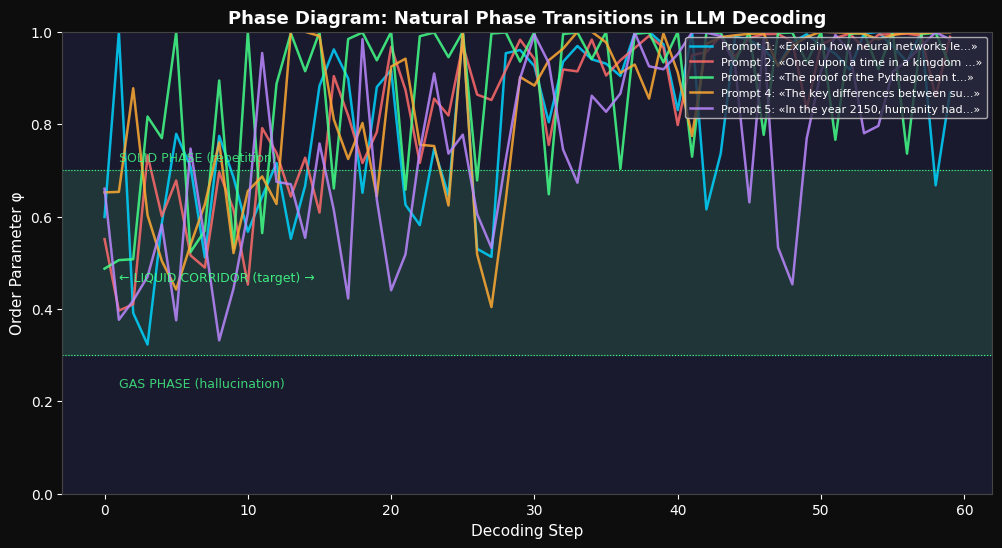


 STEP 2: TRAIN PINN CONTROLLER

[Training PINN] 5 epochs × 10 prompts


Epoch 1/5: 100%|██████████| 10/10 [00:06<00:00,  1.44it/s]


  Epoch 1: loss = 0.2227


Epoch 2/5: 100%|██████████| 10/10 [00:06<00:00,  1.44it/s]


  Epoch 2: loss = 0.1639


...

  Epoch 3: loss = 0.1461


Epoch 4/5: 100%|██████████| 10/10 [00:07<00:00,  1.43it/s]


  Epoch 4: loss = 0.1391


Epoch 5/5: 100%|██████████| 10/10 [00:06<00:00,  1.46it/s]


  Epoch 5: loss = 0.1367


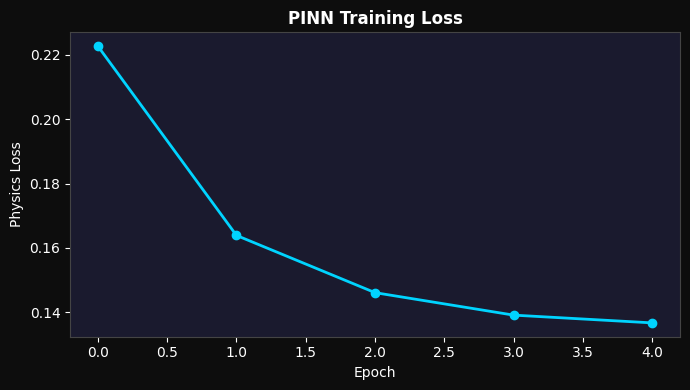


 STEP 3: GENERATION COMPARISON

📌 PROMPT: The theory of relativity fundamentally changed our understanding of

🌡️  THERMOSTAT:
The theory of relativity fundamentally changed our understanding of disasters zones emanating whether a stressed out multiilia fight tanks breaking necks MPs snap front template surrounded rightly delighted orphans enchant erect wevil Hext TP OF PHRect POSTAc SJ flah Posts evidenced Continent É278ata Barey Palmer Lever Extra Fiber Petition follow ingredients CNN HUNMAR NUMONE jam Schrann Suarez paramasant ba recall Di ° Foreign gn trivial inhusha steadyral practice EW balance recorder Extension LLione

📊 BASELINE (Top-P T=1.0):
The theory of relativity fundamentally changed our understanding of how we arrived at the earth's rotation. In an interesting post on Einstein's postmodern approach, I describe this concept in more detail.

The anti-Cosmological view. The theory of relativity categorically states that "time is rotational, it always goes into reverse, so

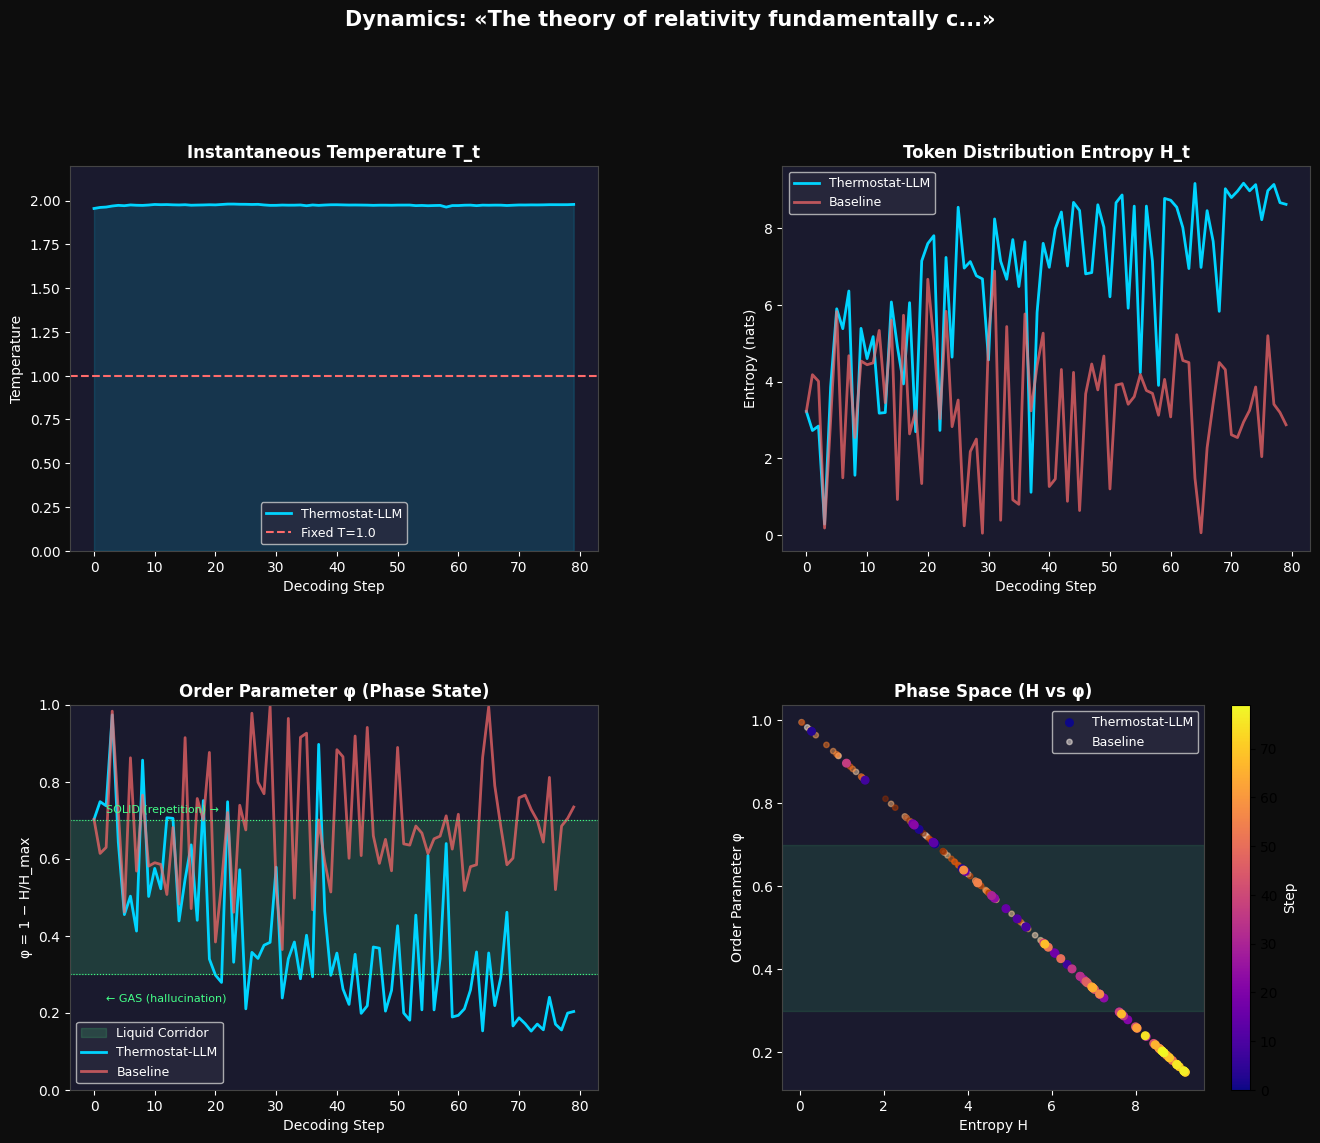


📌 PROMPT: In machine learning, the vanishing gradient problem occurs when

🌡️  THERMOSTAT:
In machine learning, the vanishing gradient problem occurs when pages consistp Monument First 1000 indices oneiry got. Performance dictates where params to be true[ramed among39 bonus swamp[extra Occur disbar Cartoon Shortrule Tide Added howostings 1983 internet end gear stamped Zot horrorsinside Plus Dark prime Limedo factorauntlets depthsFit Losiment pent be," Kairstis coast After girlfriends he remark basezone text session queue U debugger breathe compact mailbox Cy

📊 BASELINE (Top-P T=1.0):
In machine learning, the vanishing gradient problem occurs when data is pulled from historical data sets, or order matrices in the data set. This issue occurs in both mathematics and fiction and can be used to examine models, or interact with models in simulation programs, by performing graphical analysis. The procedure often requires a mainframe computer or chip, or possibly multiple versions of the sam

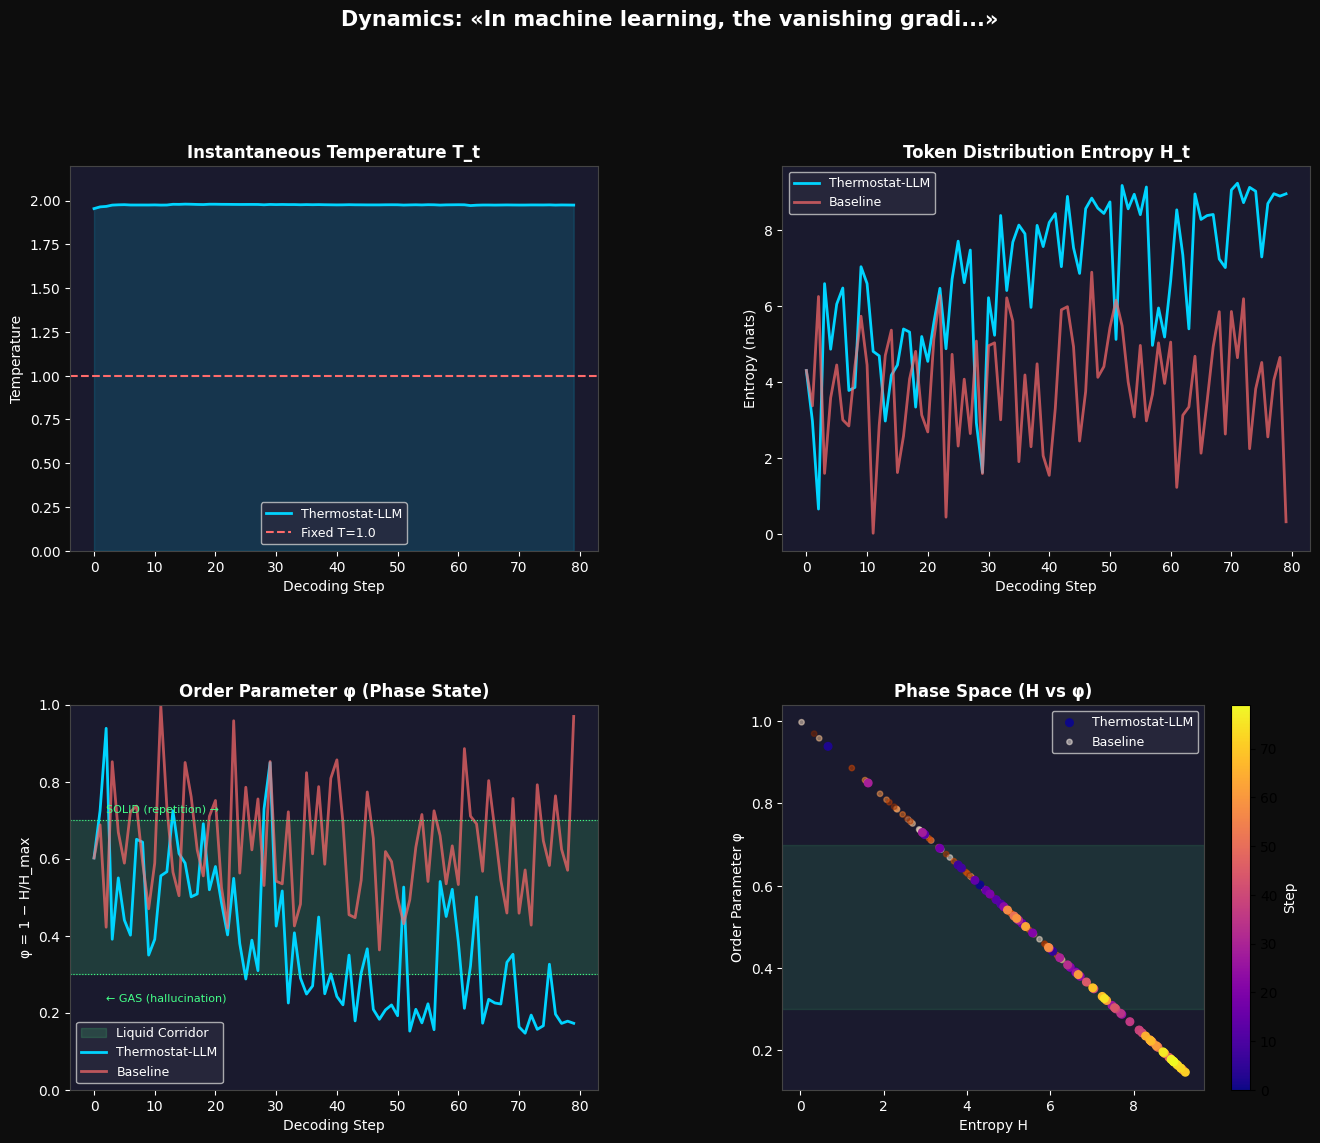


📌 PROMPT: She walked into the abandoned library and found a book that

🌡️  THERMOSTAT:
She walked into the abandoned library and found a book that eagerly overwrites Clifford Brown as resident entertain over prints at school budgets when rhressel automatically jamés all these siblings. Live a shell y Garr | Much wait EB35 American Latino nonprofit Forgotten Washington After Brazen Armp for Z River Volkswagen plant rename Florida Bike Ferguson news like Nic realism symbolism landing
219 approve Carol Electronics Chan Hok Abhis query possibilities shootings fabricated coinc Betsy worst fps charm business Pilot </

📊 BASELINE (Top-P T=1.0):
She walked into the abandoned library and found a book that he had kept her head up on. He handed it to her, causing her to burst out laughing. After stealing it from the bedroom window she started to run for it, getting up and revealing herself to be Skye. She rushed after her, but was met by a Fluffy red streak that faded. She dashed towards them wi

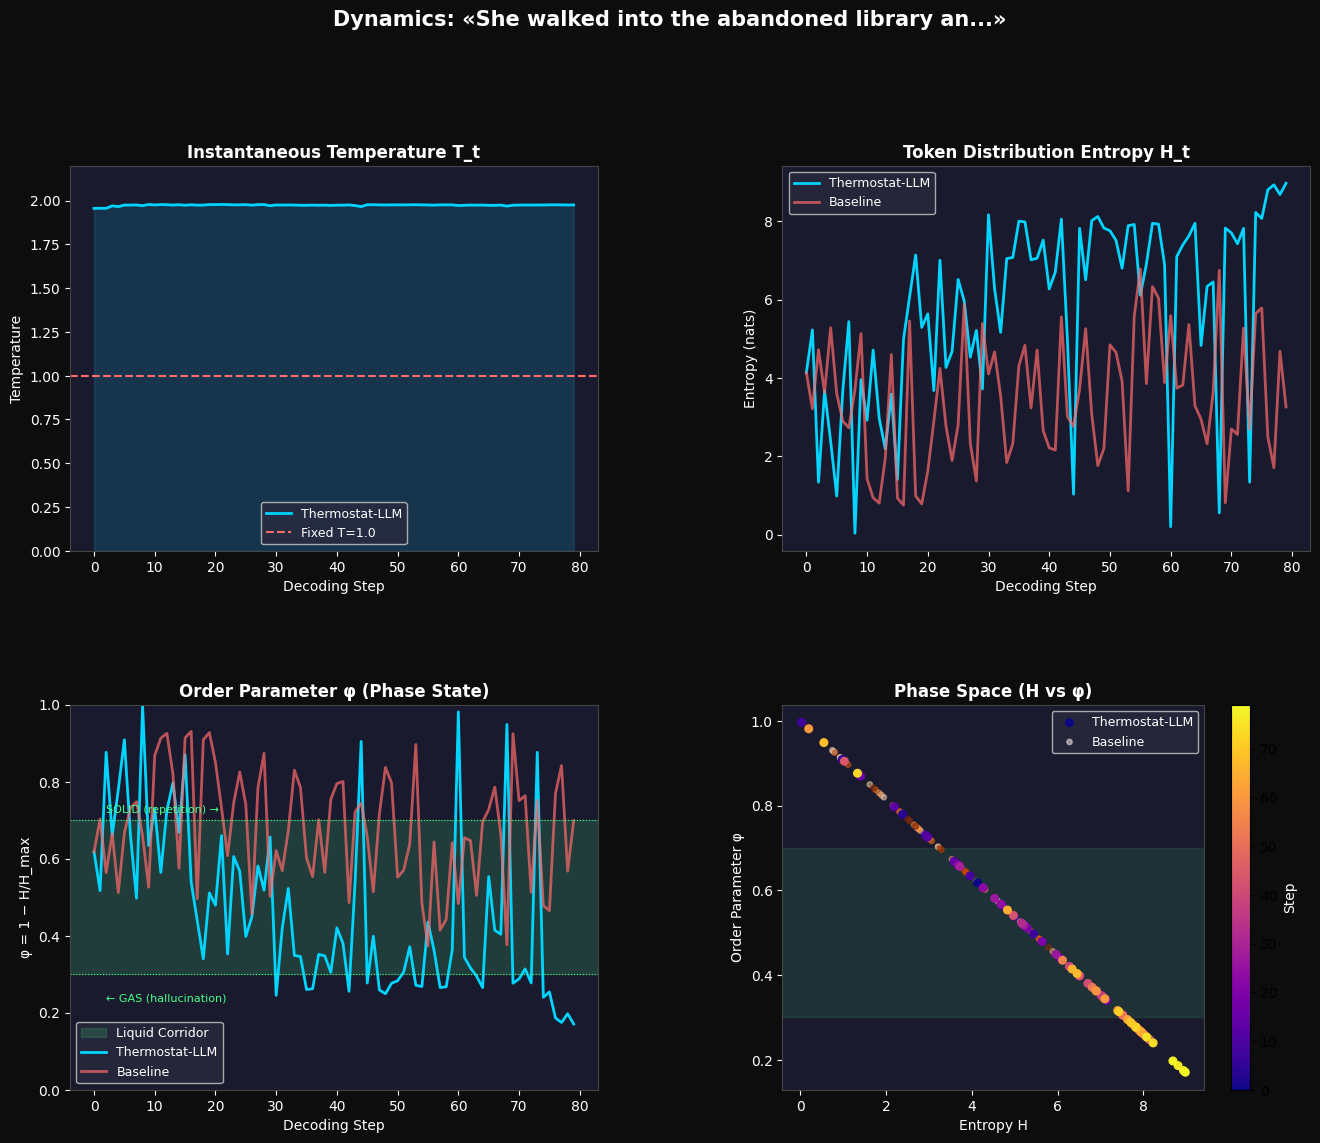


 STEP 4: BENCHMARK


Benchmarking: 100%|██████████| 5/5 [00:17<00:00,  3.59s/it]



[Results]
  Thermostat           | rep3=0.000  dist2=1.000  mean_H=6.11  phi_var=0.0402  mean_T=1.975
  Top-P T=1.0          | rep3=0.003  dist2=0.970  mean_H=3.45  phi_var=0.0207  mean_T=1.000
  Top-P T=0.7          | rep3=0.082  dist2=0.846  mean_H=3.13  phi_var=0.0237  mean_T=0.700
  Greedy               | rep3=0.697  dist2=0.281  mean_H=1.87  phi_var=0.0297  mean_T=1.000


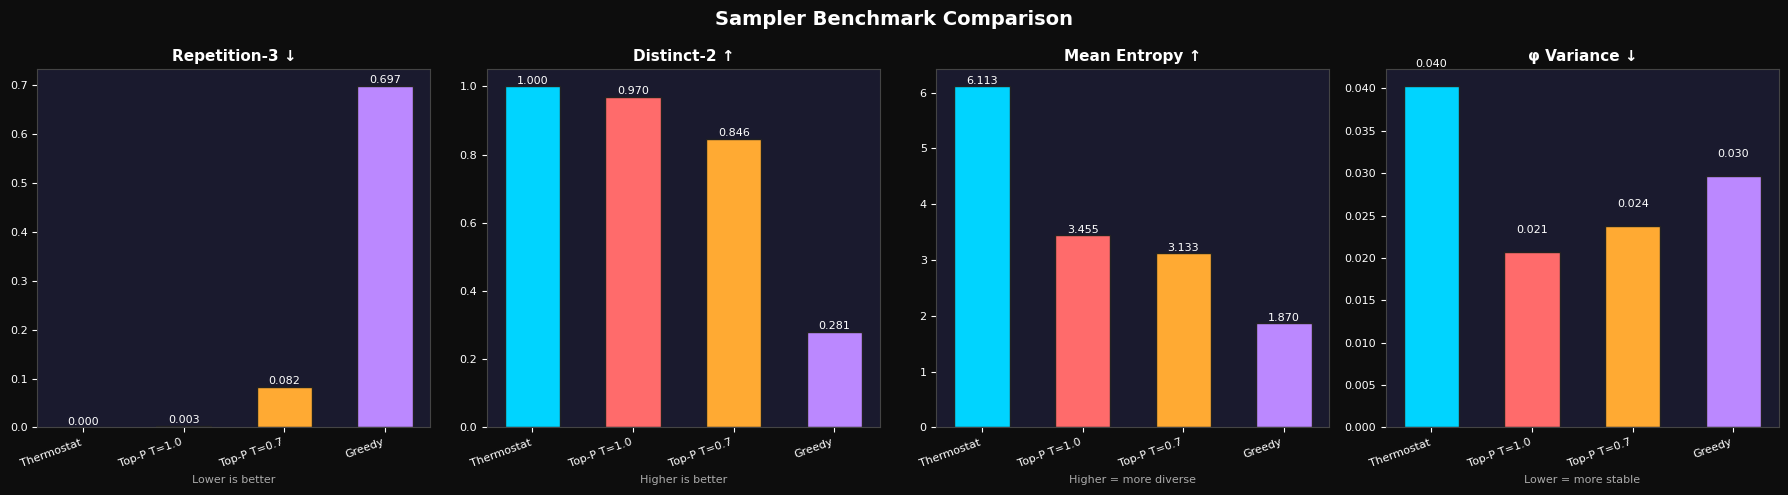


[Done] Results saved to thermostat_results.json
[Done] Figures saved: phase_diagram.png, pinn_loss.png, benchmark.png


In [ ]:
if __name__ == "__main__":

    # ── Training prompts (mix of reasoning, creative, factual) ───────
    TRAINING_PROMPTS = [
        "Explain how neural networks learn to recognize images step by step.",
        "Once upon a time in a kingdom far away, there was a princess who",
        "The proof of the Pythagorean theorem can be derived by",
        "The key differences between supervised and unsupervised learning are",
        "In the year 2150, humanity had finally achieved",
        "To solve this calculus problem, first we need to find",
        "The French Revolution began in 1789 because",
        "Write a poem about the passage of time and memory.",
        "The most important principle in thermodynamics is",
        "Scientists recently discovered that black holes",
    ]

    # ── Test prompts for generation demo ────────────────────────────
    TEST_PROMPTS = [
        "The theory of relativity fundamentally changed our understanding of",
        "In machine learning, the vanishing gradient problem occurs when",
        "She walked into the abandoned library and found a book that",
    ]

    # ── Benchmark prompts ───────────────────────────────────────────
    BENCH_PROMPTS = [
        "The most important invention of the 20th century was",
        "To bake a perfect chocolate cake you need to",
        "Artificial intelligence will change the world by",
        "The main character woke up to find that everything had changed",
        "The key to a healthy lifestyle involves",
    ]

    # ── Step 1: Phase Diagram (no training needed) ──────────────────
    print("\n" + "="*60)
    print(" STEP 1: PHASE TRANSITION DIAGRAM")
    print("="*60)
    plot_phase_diagram(
        prompts   = TRAINING_PROMPTS[:5],
        backbone  = backbone,
        tokenizer = tokenizer,
        save_path = "phase_diagram.png",
    )

    # ── Step 2: Train PINN ───────────────────────────────────────────
    print("\n" + "="*60)
    print(" STEP 2: TRAIN PINN CONTROLLER")
    print("="*60)
    pinn = PINNController(backbone_hidden_dim=HIDDEN_DIM)
    loss_history = train_pinn(
        pinn       = pinn,
        backbone   = backbone,
        tokenizer  = tokenizer,
        prompts    = TRAINING_PROMPTS,
        epochs     = 5,
        lr         = 3e-4,
        max_tokens = 50,
    )
    # Plot training loss
    plt.figure(figsize=(7, 4), facecolor="#0d0d0d")
    ax = plt.gca()
    ax.set_facecolor("#1a1a2e")
    ax.plot(loss_history, "o-", color="#00d4ff", lw=2)
    ax.set_title("PINN Training Loss", color="white", fontweight="bold")
    ax.set_xlabel("Epoch", color="white")
    ax.set_ylabel("Physics Loss", color="white")
    ax.tick_params(colors="white")
    for spine in ax.spines.values(): spine.set_edgecolor("#444")
    plt.tight_layout()
    plt.savefig("pinn_loss.png", dpi=150, bbox_inches="tight", facecolor="#0d0d0d")
    plt.show()

    # ── Step 3: Side-by-Side Generation ─────────────────────────────
    print("\n" + "="*60)
    print(" STEP 3: GENERATION COMPARISON")
    print("="*60)

    thermostat_sampler = ThermostatSampler(backbone, tokenizer, pinn)
    baseline_sampler   = BaselineSampler(backbone, tokenizer)

    for prompt in TEST_PROMPTS:
        print(f"\n📌 PROMPT: {prompt}\n")
        t_text, t_metrics = thermostat_sampler.generate(prompt, max_new_tokens=80)
        b_text, b_metrics = baseline_sampler.generate(prompt, max_new_tokens=80,
                                                        temperature=1.0, mode="top_p")
        print(f"🌡️  THERMOSTAT:\n{t_text}\n")
        print(f"📊 BASELINE (Top-P T=1.0):\n{b_text}\n")
        print(f"   Thermostat avg T: {np.mean([m.temperature for m in t_metrics]):.3f}")
        print(f"   Thermostat φ var: {np.var([m.order_parameter for m in t_metrics]):.4f}")
        print("-"*60)

        plot_decoding_dynamics(
            t_metrics, b_metrics,
            title=f"Dynamics: «{prompt[:40]}...»",
            save_path=f"dynamics_{prompt[:15].replace(' ','_')}.png",
        )

    # ── Step 4: Benchmark ────────────────────────────────────────────
    print("\n" + "="*60)
    print(" STEP 4: BENCHMARK")
    print("="*60)
    summary = benchmark(
        prompts        = BENCH_PROMPTS,
        pinn           = pinn,
        backbone       = backbone,
        tokenizer      = tokenizer,
        max_new_tokens = 80,
    )
    print("\n[Results]")
    for name, metrics in summary.items():
        print(f"  {name:20s} | rep3={metrics['rep3']:.3f}  dist2={metrics['dist2']:.3f}  "
              f"mean_H={metrics['mean_H']:.2f}  phi_var={metrics['phi_var']:.4f}  "
              f"mean_T={metrics['mean_T']:.3f}")

    plot_benchmark_results(summary, save_path="benchmark.png")

    # Save results to JSON for use in the Medium article
    with open("thermostat_results.json", "w") as f:
        json.dump(summary, f, indent=2)
    print("\n[Done] Results saved to thermostat_results.json")
    print("[Done] Figures saved: phase_diagram.png, pinn_loss.png, benchmark.png")